# ANÁLISIS DE CALIDAD DE DATOS - Ingresos Municipalidades (SIAF)

---

## Contexto del Proyecto

### Descripción del Problema
El **Ministerio de Economía y Finanzas (MEF)**, a través del Sistema Integrado de
Administración Financiera (SIAF), registra el presupuesto y ejecución de ingresos
de todos los niveles de gobierno. Sin embargo, al consolidar los datos históricos
de municipalidades (2012-2026), se detectan inconsistencias en los montos
reportados, registros de niveles de gobierno no municipales mezclados, y valores
faltantes en columnas clave que afectan el análisis presupuestal.

### Objetivo Analítico
Evaluar y mejorar la calidad de los datos de ingresos históricos del SIAF para:
- Generar reportes confiables de ejecución presupuestal por municipalidad
- Filtrar correctamente solo Gobiernos Locales (NIVEL_GOBIERNO = 'M')
- Identificar municipalidades con mejor y peor desempeño en recaudación
- Preparar los datos para el modelo estrella en la capa Gold

### Impacto de la Mala Calidad de Datos
- **Financiero**: Montos de PIA, PIM o MONTO_RECAUDADO incorrectos llevan
a calcular mal el porcentaje de ejecución presupuestal por municipalidad
- **Operativo**: Registros de gobiernos nacionales o regionales mezclados con
municipalidades distorsionan los rankings y comparativos
- **Estratégico**: Decisiones de política pública basadas en datos incompletos
pueden derivar en asignaciones presupuestales inequitativas entre municipios

---

## Dimensiones de Calidad a Evaluar

En este caso trabajaremos con:

1. **Completitud**: ¿Tenemos todos los registros de municipalidades del 2012
al 2026 con sus montos completos?
2. **Exactitud**: ¿Los valores de MONTO_PIA, MONTO_PIM y MONTO_RECAUDADO
son correctos y coherentes?
3. **Consistencia**: ¿Los datos de NIVEL_GOBIERNO, RUBRO y EJECUTORA son
coherentes a lo largo de todos los años?
4. **Integridad**: ¿Cada registro tiene su Ubigeo válido que permita
relacionarlo con RENAMU y SISMEPRE?
5. **Razonabilidad**: ¿Los montos recaudados están dentro de rangos esperados?
¿Hay valores negativos o extremadamente altos?
6. **Oportunidad**: ¿Los datos cubren el rango completo 2012-2026 sin años
faltantes o incompletos?
7. **Unicidad**: ¿Existen registros duplicados por año, municipalidad y rubro?
8. **Validez**: ¿Los formatos de códigos (UBIGEO, NIVEL_GOBIERNO, RUBRO)
son correctos y estandarizados?

---

In [4]:
# Instalación de librerías necesarias
# !pip install pandas numpy matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

print("✅ Librerías cargadas correctamente")


✅ Librerías cargadas correctamente


## Carga del Dataset

Cargaremos el dataset de Ingresos Históricos del SIAF que contiene los registros
de presupuesto y ejecución de ingresos de todos los niveles de gobierno
del período 2012-2026, consolidado en un solo archivo CSV.

In [5]:
# Cargar datos desde el archivo CSV
df = pd.read_csv('INGRESOS_HISTORICO_TOTAL_2012_2026.csv', encoding='latin-1')

print(f"Dataset cargado correctamente")
print(f"Total de registros: {len(df):,}")
print(f"Total de columnas: {len(df.columns)}")
print(f"Columnas: {list(df.columns)}")
print(f"\nRango de años: {df['ANO_DOC'].min()} a {df['ANO_DOC'].max()}")
print(f"Niveles de gobierno: {df['NIVEL_GOBIERNO'].unique()}")
print(f"Registros de Municipalidades (M): {len(df[df['NIVEL_GOBIERNO'] == 'M']):,}")

Dataset cargado correctamente
Total de registros: 10,777,068
Total de columnas: 37
Columnas: ['ANO_DOC', 'MES_DOC', 'NIVEL_GOBIERNO', 'NIVEL_GOBIERNO_NOMBRE', 'SECTOR', 'SECTOR_NOMBRE', 'PLIEGO', 'PLIEGO_NOMBRE', 'SEC_EJEC', 'EJECUTORA', 'EJECUTORA_NOMBRE', 'DEPARTAMENTO_EJECUTORA', 'DEPARTAMENTO_EJECUTORA_NOMBRE', 'PROVINCIA_EJECUTORA', 'PROVINCIA_EJECUTORA_NOMBRE', 'DISTRITO_EJECUTORA', 'DISTRITO_EJECUTORA_NOMBRE', 'FUENTE_FINANCIAMIENTO', 'FUENTE_FINANCIAMIENTO_NOMBRE', 'RUBRO', 'RUBRO_NOMBRE', 'TIPO_RECURSO', 'TIPO_RECURSO_NOMBRE', 'GENERICA', 'GENERICA_NOMBRE', 'SUBGENERICA', 'SUBGENERICA_NOMBRE', 'SUBGENERICA_DET', 'SUBGENERICA_DET_NOMBRE', 'ESPECIFICA', 'ESPECIFICA_NOMBRE', 'ESPECIFICA_DET', 'ESPECIFICA_DET_NOMBRE', 'MONTO_PIA', 'MONTO_PIM', 'MONTO_RECAUDADO', 'ARCHIVO_ORIGEN']

Rango de años: 2012 a 2026
Niveles de gobierno: <StringArray>
['R', 'M', 'E']
Length: 3, dtype: str
Registros de Municipalidades (M): 8,880,692


In [6]:
# Vista previa del dataset
df.head(10)

,ANO_DOC,MES_DOC,NIVEL_GOBIERNO,NIVEL_GOBIERNO_NOMBRE,SECTOR,SECTOR_NOMBRE,PLIEGO,PLIEGO_NOMBRE,SEC_EJEC,EJECUTORA,...,SUBGENERICA_DET,SUBGENERICA_DET_NOMBRE,ESPECIFICA,ESPECIFICA_NOMBRE,ESPECIFICA_DET,ESPECIFICA_DET_NOMBRE,MONTO_PIA,MONTO_PIM,MONTO_RECAUDADO,ARCHIVO_ORIGEN
0,2012,1,R,GOBIERNOS REGIONALES,99,GOBIERNOS REGIONALES,440,GOBIERNO REGIONAL AMAZONAS,721,1,...,4,VENTA DE PRODUCTOS INDUSTRIALES,1,VENTA DE PRODUCTOS INDUSTRIALES,3,VENTA DE PRODUCTOS HIDROBIOLOGICOS,44789,44789,577.00,2012-Ingreso.csv
1,2012,1,R,GOBIERNOS REGIONALES,99,GOBIERNOS REGIONALES,440,GOBIERNO REGIONAL AMAZONAS,721,1,...,4,VENTA DE PRODUCTOS INDUSTRIALES,1,VENTA DE PRODUCTOS INDUSTRIALES,4,PRODUCTOS TEXTILES,0,0,0.00,2012-Ingreso.csv
2,2012,1,R,GOBIERNOS REGIONALES,99,GOBIERNOS REGIONALES,440,GOBIERNO REGIONAL AMAZONAS,721,1,...,9,VENTA DE OTROS BIENES,1,VENTA DE OTROS BIENES,2,"VENTA DE BASES PARA LICITACION PUBLICA, CONCUR...",17500,17500,1230.00,2012-Ingreso.csv
3,2012,1,R,GOBIERNOS REGIONALES,99,GOBIERNOS REGIONALES,440,GOBIERNO REGIONAL AMAZONAS,721,1,...,1,DERECHOS ADMINISTRATIVOS GENERALES,1,REGISTROS Y LICENCIAS,1,REGISTRO CIVIL,0,0,0.00,2012-Ingreso.csv
4,2012,1,R,GOBIERNOS REGIONALES,99,GOBIERNOS REGIONALES,440,GOBIERNO REGIONAL AMAZONAS,721,1,...,1,DERECHOS ADMINISTRATIVOS GENERALES,1,REGISTROS Y LICENCIAS,99,OTROS REGISTROS,31706,31706,5515.96,2012-Ingreso.csv
5,2012,1,R,GOBIERNOS REGIONALES,99,GOBIERNOS REGIONALES,440,GOBIERNO REGIONAL AMAZONAS,721,1,...,3,DERECHOS ADMINISTRATIVOS DE EDUCACION,1,DERECHOS ADMINISTRATIVOS DE EDUCACION,4,CONSTANCIAS Y CERTIFICADOS,28600,28600,0.00,2012-Ingreso.csv
6,2012,1,R,GOBIERNOS REGIONALES,99,GOBIERNOS REGIONALES,440,GOBIERNO REGIONAL AMAZONAS,721,1,...,7,DERECHOS ADMINISTRATIVOS DE ENERGIA Y MINAS,1,DERECHOS ADMINISTRATIVOS DE MINERIA,1,DERECHO DE APROBACION Y AUTORIZACION,0,0,1253.00,2012-Ingreso.csv
7,2012,1,R,GOBIERNOS REGIONALES,99,GOBIERNOS REGIONALES,440,GOBIERNO REGIONAL AMAZONAS,721,1,...,7,DERECHOS ADMINISTRATIVOS DE ENERGIA Y MINAS,1,DERECHOS ADMINISTRATIVOS DE MINERIA,7,EVALUACIÃN,0,0,0.00,2012-Ingreso.csv
8,2012,1,R,GOBIERNOS REGIONALES,99,GOBIERNOS REGIONALES,440,GOBIERNO REGIONAL AMAZONAS,721,1,...,7,DERECHOS ADMINISTRATIVOS DE ENERGIA Y MINAS,3,DERECHOS ADMINISTRATIVOS DE HIDROCARBUROS,1,DERECHO DE APROBACION Y AUTORIZACION,0,0,1825.00,2012-Ingreso.csv
9,2012,1,R,GOBIERNOS REGIONALES,99,GOBIERNOS REGIONALES,440,GOBIERNO REGIONAL AMAZONAS,721,1,...,9,DERECHOS ADMINISTRATIVOS DE INDUSTRIA Y COMERCIO,1,DERECHOS ADMINISTRATIVOS DE INDUSTRIA Y COMERCIO,2,CERTIFICACIONES Y MANIFESTACIONES,22395,22395,0.00,2012-Ingreso.csv


In [7]:
# Información general del dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10777068 entries, 0 to 10777067
Data columns (total 37 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   ANO_DOC                        int64  
 1   MES_DOC                        int64  
 2   NIVEL_GOBIERNO                 str    
 3   NIVEL_GOBIERNO_NOMBRE          str    
 4   SECTOR                         object 
 5   SECTOR_NOMBRE                  str    
 6   PLIEGO                         object 
 7   PLIEGO_NOMBRE                  str    
 8   SEC_EJEC                       int64  
 9   EJECUTORA                      int64  
 10  EJECUTORA_NOMBRE               str    
 11  DEPARTAMENTO_EJECUTORA         object 
 12  DEPARTAMENTO_EJECUTORA_NOMBRE  str    
 13  PROVINCIA_EJECUTORA            object 
 14  PROVINCIA_EJECUTORA_NOMBRE     str    
 15  DISTRITO_EJECUTORA             object 
 16  DISTRITO_EJECUTORA_NOMBRE      str    
 17  FUENTE_FINANCIAMIENTO          int64  
 18  FUENTE_FINA

---

## Análisis de Calidad de Datos

### 1. COMPLETITUD - Análisis de Datos Faltantes

In [8]:
# Calcular porcentaje de valores faltantes
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

# Crear DataFrame con resultados
completitud = pd.DataFrame({
    'Faltantes': missing_data,
    'Porcentaje': missing_percent
}).sort_values('Porcentaje', ascending=False)

print("=" * 55)
print("   ANÁLISIS DE COMPLETITUD - INGRESOS SIAF 2012-2026")
print("=" * 55)
print(f"\nTotal de registros analizados: {len(df):,}")
print(f"Total de columnas: {len(df.columns)}")
print("\nColumnas con valores faltantes:")
print("-" * 55)
print(completitud[completitud['Faltantes'] > 0].to_string())
print("-" * 55)

# Columnas críticas para el análisis de municipalidades
columnas_criticas = [
    'NIVEL_GOBIERNO', 'EJECUTORA_NOMBRE',
    'DEPARTAMENTO_EJECUTORA_NOMBRE', 'RUBRO_NOMBRE',
    'MONTO_PIA', 'MONTO_PIM', 'MONTO_RECAUDADO'
]

print("\n📌 Completitud en columnas CRÍTICAS:")
print("-" * 55)
for col in columnas_criticas:
    faltantes = df[col].isnull().sum()
    porcentaje = (faltantes / len(df)) * 100
    estado = "✅ OK" if porcentaje == 0 else "⚠️ REVISAR"
    print(f"{estado} {col}: {faltantes:,} faltantes ({porcentaje:.2f}%)")

# Visualización solo columnas con datos faltantes
cols_con_faltantes = completitud[completitud['Porcentaje'] > 0]

if len(cols_con_faltantes) > 0:
    plt.figure(figsize=(12, 6))
    bars = plt.bar(
        cols_con_faltantes.index,
        cols_con_faltantes['Porcentaje'],
        color=['#e74c3c' if p > 10 else '#f39c12' if p > 5 else '#f1c40f'
               for p in cols_con_faltantes['Porcentaje']]
    )
    plt.title(
        'Porcentaje de Datos Faltantes por Columna\nIngresos SIAF 2012-2026',
        fontsize=13, fontweight='bold'
    )
    plt.ylabel('Porcentaje de Faltantes (%)')
    plt.xlabel('Columnas')
    plt.xticks(rotation=45, ha='right')
    # Agregar etiquetas encima de cada barra
    for bar, val in zip(bars, cols_con_faltantes['Porcentaje']):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.1,
            f'{val:.1f}%',
            ha='center', va='bottom', fontsize=9
        )
    plt.tight_layout()
    plt.show()
else:
    print("\n✅ No se encontraron valores faltantes en ninguna columna.")

   ANÁLISIS DE COMPLETITUD - INGRESOS SIAF 2012-2026

Total de registros analizados: 10,777,068
Total de columnas: 37

Columnas con valores faltantes:
-------------------------------------------------------
Empty DataFrame
Columns: [Faltantes, Porcentaje]
Index: []
-------------------------------------------------------

📌 Completitud en columnas CRÍTICAS:
-------------------------------------------------------
✅ OK NIVEL_GOBIERNO: 0 faltantes (0.00%)
✅ OK EJECUTORA_NOMBRE: 0 faltantes (0.00%)
✅ OK DEPARTAMENTO_EJECUTORA_NOMBRE: 0 faltantes (0.00%)
✅ OK RUBRO_NOMBRE: 0 faltantes (0.00%)
✅ OK MONTO_PIA: 0 faltantes (0.00%)
✅ OK MONTO_PIM: 0 faltantes (0.00%)
✅ OK MONTO_RECAUDADO: 0 faltantes (0.00%)

✅ No se encontraron valores faltantes en ninguna columna.


### 2. EXACTITUD - Validación de Valores Numéricos

   ANÁLISIS DE EXACTITUD - MONTOS PRESUPUESTALES
   Solo Gobiernos Locales (NIVEL_GOBIERNO = 'M')

Total registros municipalidades: 8,880,692

📌 Validación de montos:
------------------------------------------------------------
⚠️  MONTO_PIA negativos    : 0 (0.00%)
⚠️  MONTO_PIM negativos    : 13,503 (0.15%)
⚠️  MONTO_RECAUDADO negat. : 62,726 (0.71%)
⚠️  PIM menor que PIA      : 31,772 (0.36%)
⚠️  Recaudado > 2x PIM     : 6,356,653 (71.58%)

📋 Ejemplos de MONTO_PIA negativos:
------------------------------------------------------------
✅ No se encontraron valores negativos en MONTO_PIA

📋 Ejemplos de MONTO_RECAUDADO negativos:
------------------------------------------------------------
       ANO_DOC                         EJECUTORA_NOMBRE  \
70705     2012  MUNICIPALIDAD PROVINCIAL DE CHACHAPOYAS   
70815     2012  MUNICIPALIDAD PROVINCIAL DE CHACHAPOYAS   
70869     2012  MUNICIPALIDAD PROVINCIAL DE CHACHAPOYAS   
70870     2012  MUNICIPALIDAD PROVINCIAL DE CHACHAPOYAS   
70871  

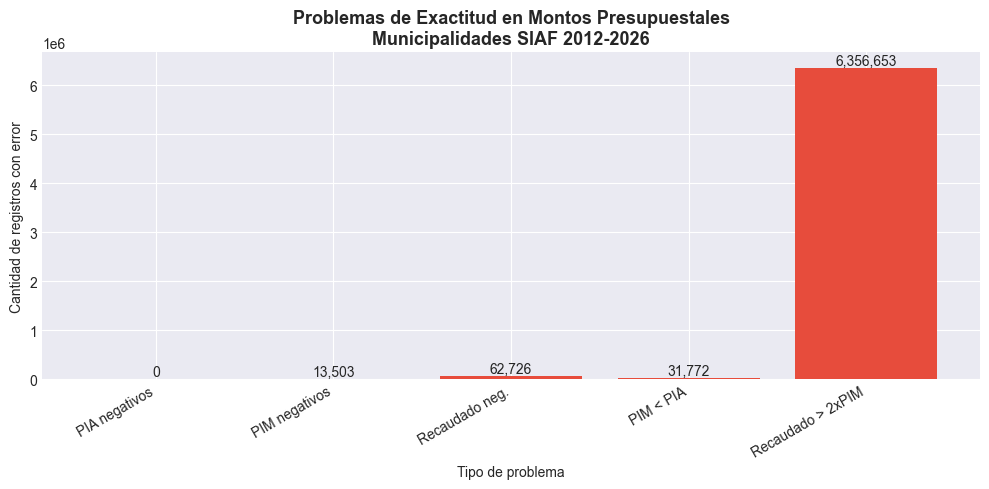

In [10]:
# Detectar montos incorrectos en columnas financieras clave

# Filtrar solo municipalidades para el análisis
df_munic = df[df['NIVEL_GOBIERNO'] == 'M'].copy()

# Detectar problemas en montos
pia_negativos      = df_munic[df_munic['MONTO_PIA'] < 0]
pim_negativos      = df_munic[df_munic['MONTO_PIM'] < 0]
recaudado_negativos = df_munic[df_munic['MONTO_RECAUDADO'] < 0]
pim_menor_pia      = df_munic[df_munic['MONTO_PIM'] < df_munic['MONTO_PIA']]
recaudado_mayor_pim = df_munic[df_munic['MONTO_RECAUDADO'] > df_munic['MONTO_PIM'] * 2]

print("=" * 60)
print("   ANÁLISIS DE EXACTITUD - MONTOS PRESUPUESTALES")
print("   Solo Gobiernos Locales (NIVEL_GOBIERNO = 'M')")
print("=" * 60)
print(f"\nTotal registros municipalidades: {len(df_munic):,}")

print("\n📌 Validación de montos:")
print("-" * 60)
print(f"⚠️  MONTO_PIA negativos    : {len(pia_negativos):,} "
      f"({len(pia_negativos)/len(df_munic)*100:.2f}%)")
print(f"⚠️  MONTO_PIM negativos    : {len(pim_negativos):,} "
      f"({len(pim_negativos)/len(df_munic)*100:.2f}%)")
print(f"⚠️  MONTO_RECAUDADO negat. : {len(recaudado_negativos):,} "
      f"({len(recaudado_negativos)/len(df_munic)*100:.2f}%)")
print(f"⚠️  PIM menor que PIA      : {len(pim_menor_pia):,} "
      f"({len(pim_menor_pia)/len(df_munic)*100:.2f}%)")
print(f"⚠️  Recaudado > 2x PIM     : {len(recaudado_mayor_pim):,} "
      f"({len(recaudado_mayor_pim)/len(df_munic)*100:.2f}%)")

# Mostrar ejemplos de errores encontrados
print("\n📋 Ejemplos de MONTO_PIA negativos:")
print("-" * 60)
if len(pia_negativos) > 0:
    print(pia_negativos[['ANO_DOC', 'EJECUTORA_NOMBRE',
                          'RUBRO_NOMBRE', 'MONTO_PIA',
                          'MONTO_PIM', 'MONTO_RECAUDADO']].head())
else:
    print("✅ No se encontraron valores negativos en MONTO_PIA")

print("\n📋 Ejemplos de MONTO_RECAUDADO negativos:")
print("-" * 60)
if len(recaudado_negativos) > 0:
    print(recaudado_negativos[['ANO_DOC', 'EJECUTORA_NOMBRE',
                               'RUBRO_NOMBRE', 'MONTO_PIA',
                               'MONTO_PIM', 'MONTO_RECAUDADO']].head())
else:
    print("✅ No se encontraron valores negativos en MONTO_RECAUDADO")

print("\n📋 Ejemplos donde PIM < PIA (posible error de registro):")
print("-" * 60)
if len(pim_menor_pia) > 0:
    print(pim_menor_pia[['ANO_DOC', 'EJECUTORA_NOMBRE',
                          'RUBRO_NOMBRE', 'MONTO_PIA',
                          'MONTO_PIM', 'MONTO_RECAUDADO']].head())
else:
    print("✅ No se encontraron casos donde PIM < PIA")

# Visualización resumen de exactitud
problemas = {
    'PIA negativos': len(pia_negativos),
    'PIM negativos': len(pim_negativos),
    'Recaudado neg.': len(recaudado_negativos),
    'PIM < PIA': len(pim_menor_pia),
    'Recaudado > 2xPIM': len(recaudado_mayor_pim)
}

plt.figure(figsize=(10, 5))
bars = plt.bar(
    problemas.keys(),
    problemas.values(),
    color=['#e74c3c' if v > 0 else '#2ecc71' for v in problemas.values()]
)
plt.title(
    'Problemas de Exactitud en Montos Presupuestales\nMunicipalidades SIAF 2012-2026',
    fontsize=13, fontweight='bold'
)
plt.ylabel('Cantidad de registros con error')
plt.xlabel('Tipo de problema')
plt.xticks(rotation=30, ha='right')
for bar, val in zip(bars, problemas.values()):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{val:,}',
        ha='center', va='bottom', fontsize=10
    )
plt.tight_layout()
plt.show()

### 3. CONSISTENCIA - Coherencia entre Campos

   ANÁLISIS DE CONSISTENCIA - INGRESOS MUNICIPALIDADES

Total registros municipalidades: 8,880,692

📌 Consistencia entre código y nombre de NIVEL_GOBIERNO:
------------------------------------------------------------
⚠️  Inconsistencias: 0 (0.00%)
✅ Código y nombre de nivel de gobierno son consistentes

📌 Consistencia entre FUENTE_FINANCIAMIENTO y su nombre:
------------------------------------------------------------
✅ Todos los códigos de fuente tienen un único nombre

📌 Consistencia entre RUBRO y su nombre:
------------------------------------------------------------
✅ Todos los códigos de rubro tienen un único nombre

📌 Consistencia entre ANO_DOC y año del archivo origen:
------------------------------------------------------------
⚠️  Registros con año inconsistente: 0 (0.00%)
✅ El año del documento coincide con el archivo de origen


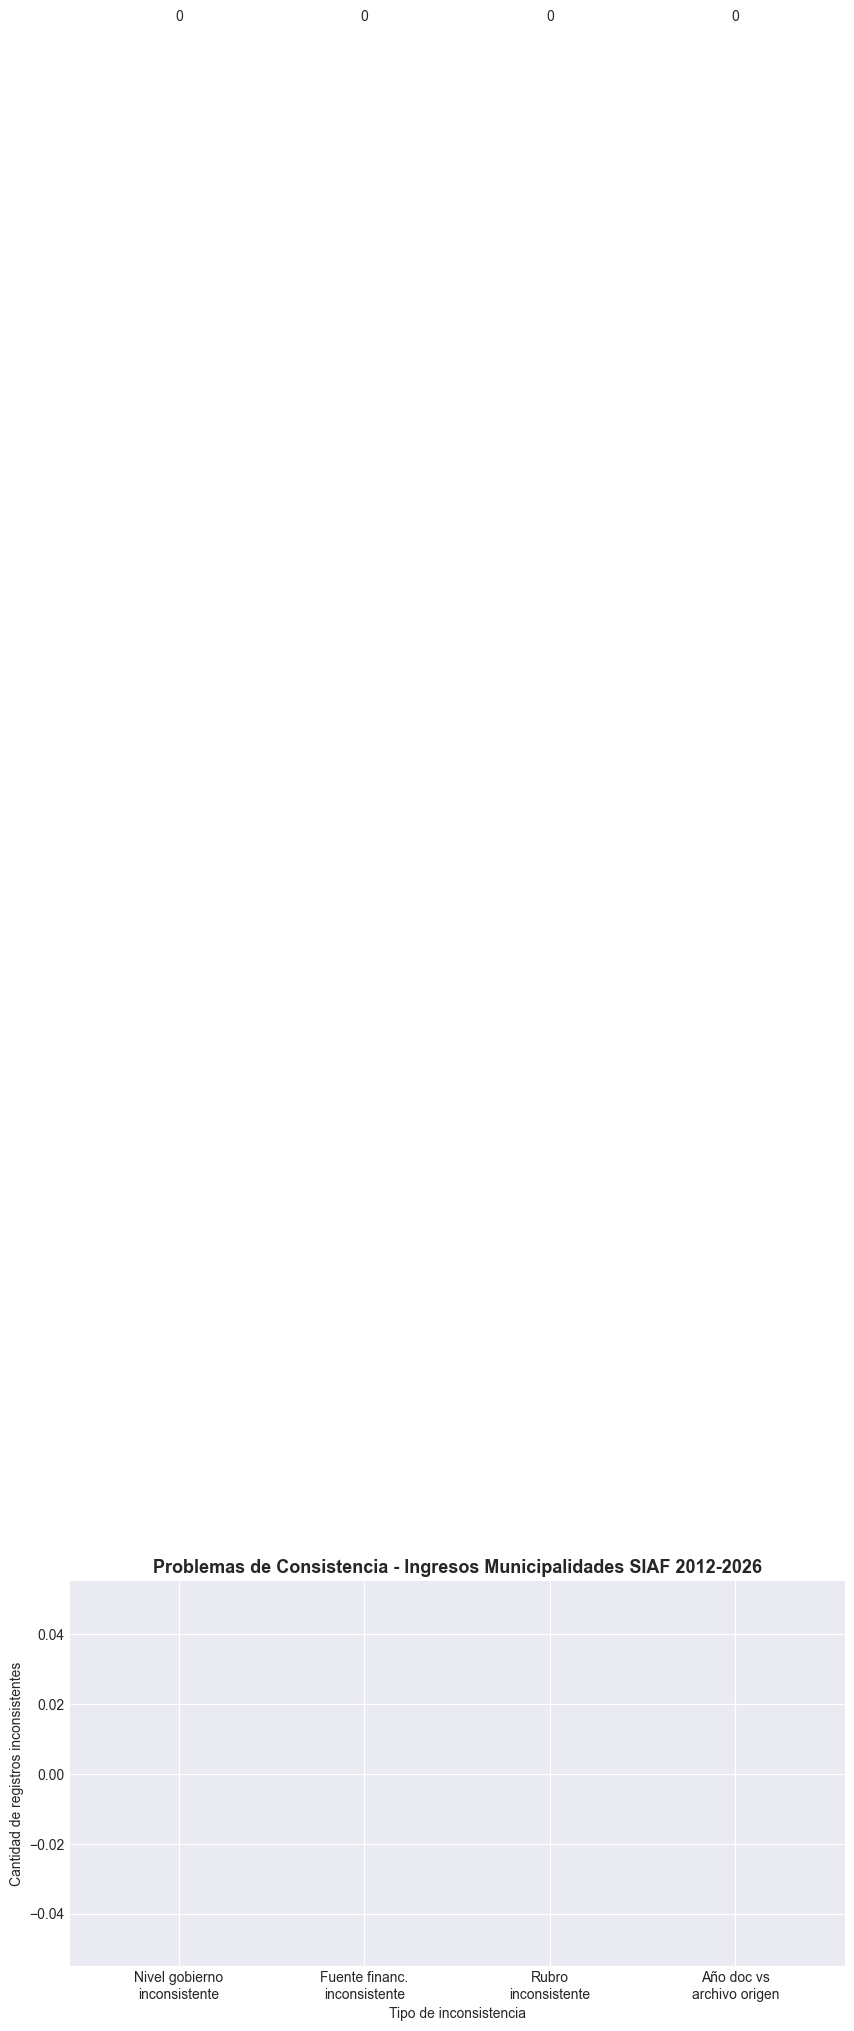

In [11]:
# Trabajamos con el filtro de municipalidades
df_munic = df[df['NIVEL_GOBIERNO'] == 'M'].copy()

# 1. Consistencia entre NIVEL_GOBIERNO y NIVEL_GOBIERNO_NOMBRE
reglas_nivel = {
    'E': 'GOBIERNO NACIONAL',
    'R': 'GOBIERNOS REGIONALES',
    'M': 'GOBIERNOS LOCALES'
}

df_munic['NIVEL_NOMBRE_ESPERADO'] = df_munic['NIVEL_GOBIERNO'].map(reglas_nivel)
inconsist_nivel = df_munic[
    df_munic['NIVEL_GOBIERNO_NOMBRE'] != df_munic['NIVEL_NOMBRE_ESPERADO']
]

# 2. Consistencia entre FUENTE_FINANCIAMIENTO y FUENTE_FINANCIAMIENTO_NOMBRE
# Verificar que el código y nombre de fuente siempre van juntos igual
fuente_check = df_munic.groupby('FUENTE_FINANCIAMIENTO')[
    'FUENTE_FINANCIAMIENTO_NOMBRE'
].nunique()
fuentes_inconsistentes = fuente_check[fuente_check > 1]

# 3. Consistencia entre RUBRO y RUBRO_NOMBRE
rubro_check = df_munic.groupby('RUBRO')['RUBRO_NOMBRE'].nunique()
rubros_inconsistentes = rubro_check[rubro_check > 1]

# 4. Consistencia temporal: ANO_DOC debe coincidir con ARCHIVO_ORIGEN
df_munic['ANO_ORIGEN'] = df_munic['ARCHIVO_ORIGEN'].str.extract(r'(\d{4})').astype(float)
inconsist_anio = df_munic[df_munic['ANO_DOC'] != df_munic['ANO_ORIGEN']]

print("=" * 60)
print("   ANÁLISIS DE CONSISTENCIA - INGRESOS MUNICIPALIDADES")
print("=" * 60)
print(f"\nTotal registros municipalidades: {len(df_munic):,}")

print("\n📌 Consistencia entre código y nombre de NIVEL_GOBIERNO:")
print("-" * 60)
print(f"⚠️  Inconsistencias: {len(inconsist_nivel):,} "
      f"({len(inconsist_nivel)/len(df_munic)*100:.2f}%)")
if len(inconsist_nivel) > 0:
    print(inconsist_nivel[['NIVEL_GOBIERNO',
                            'NIVEL_GOBIERNO_NOMBRE',
                            'NIVEL_NOMBRE_ESPERADO']].head())
else:
    print("✅ Código y nombre de nivel de gobierno son consistentes")

print("\n📌 Consistencia entre FUENTE_FINANCIAMIENTO y su nombre:")
print("-" * 60)
if len(fuentes_inconsistentes) > 0:
    print(f"⚠️  Fuentes con nombres inconsistentes: "
          f"{len(fuentes_inconsistentes)}")
    print(fuentes_inconsistentes)
else:
    print("✅ Todos los códigos de fuente tienen un único nombre")

print("\n📌 Consistencia entre RUBRO y su nombre:")
print("-" * 60)
if len(rubros_inconsistentes) > 0:
    print(f"⚠️  Rubros con nombres inconsistentes: "
          f"{len(rubros_inconsistentes)}")
    print(rubros_inconsistentes)
else:
    print("✅ Todos los códigos de rubro tienen un único nombre")

print("\n📌 Consistencia entre ANO_DOC y año del archivo origen:")
print("-" * 60)
print(f"⚠️  Registros con año inconsistente: {len(inconsist_anio):,} "
      f"({len(inconsist_anio)/len(df_munic)*100:.2f}%)")
if len(inconsist_anio) > 0:
    print(inconsist_anio[['ANO_DOC', 'ARCHIVO_ORIGEN',
                           'ANO_ORIGEN', 'EJECUTORA_NOMBRE']].head())
else:
    print("✅ El año del documento coincide con el archivo de origen")

# Visualización resumen de consistencia
problemas_consist = {
    'Nivel gobierno\ninconsistente': len(inconsist_nivel),
    'Fuente financ.\ninconsistente': len(fuentes_inconsistentes),
    'Rubro\ninconsistente': len(rubros_inconsistentes),
    'Año doc vs\narchivo origen': len(inconsist_anio)
}

plt.figure(figsize=(10, 5))
bars = plt.bar(
    problemas_consist.keys(),
    problemas_consist.values(),
    color=['#e74c3c' if v > 0 else '#2ecc71'
           for v in problemas_consist.values()]
)
plt.title(
    'Problemas de Consistencia - Ingresos Municipalidades SIAF 2012-2026',
    fontsize=13, fontweight='bold'
)
plt.ylabel('Cantidad de registros inconsistentes')
plt.xlabel('Tipo de inconsistencia')
for bar, val in zip(bars, problemas_consist.values()):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{val:,}',
        ha='center', va='bottom', fontsize=10
    )
plt.tight_layout()
plt.show()

### 4. INTEGRIDAD - Validación de IDs

   ANÁLISIS DE INTEGRIDAD - INGRESOS MUNICIPALIDADES

Total registros municipalidades: 8,880,692

📌 Validación de UBIGEO (debe tener 6 dígitos):
------------------------------------------------------------
⚠️  UBIGEOs inválidos: 0 (0.00%)
✅ Todos los UBIGEOs tienen formato de 6 dígitos

📌 Validación de DEPARTAMENTO_EJECUTORA (rango 01-25):
------------------------------------------------------------
⚠️  Departamentos fuera de rango: 36 (0.00%)
        ANO_DOC                         EJECUTORA_NOMBRE  \
709404     2012  MANCOMUNIDAD MUNICIPAL DE HUAYTAPALLANA   
709405     2012  MANCOMUNIDAD MUNICIPAL DE HUAYTAPALLANA   
709406     2012  MANCOMUNIDAD MUNICIPAL DE HUAYTAPALLANA   
709407     2012  MANCOMUNIDAD MUNICIPAL DE HUAYTAPALLANA   
709408     2012  MANCOMUNIDAD MUNICIPAL DE HUAYTAPALLANA   

       DEPARTAMENTO_EJECUTORA DEPARTAMENTO_EJECUTORA_NOMBRE  
709404                                                       
709405                                                       
70940

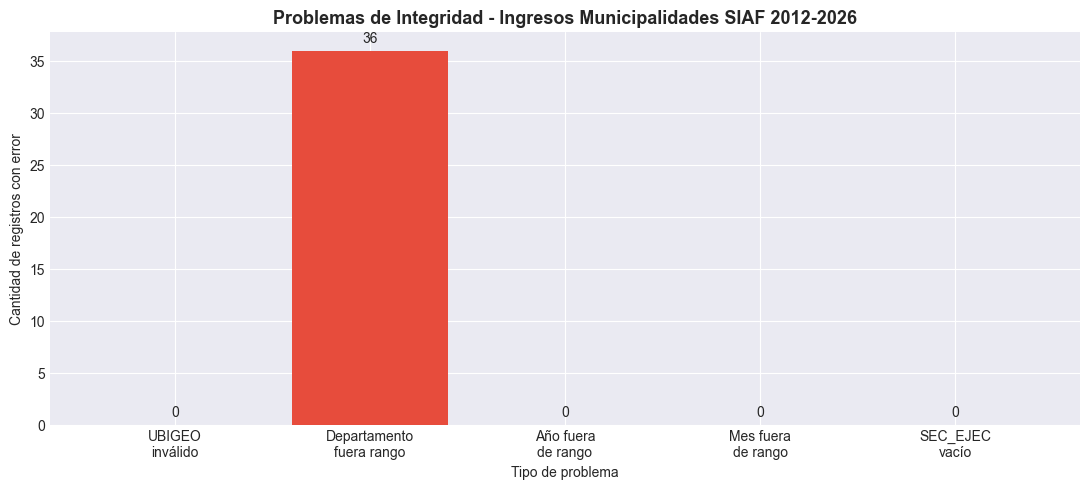

In [12]:
# Trabajamos con el filtro de municipalidades
df_munic = df[df['NIVEL_GOBIERNO'] == 'M'].copy()

# 1. Validar formato de UBIGEO (debe ser 6 dígitos numéricos)
# El ubigeo en Perú: 2 dígitos departamento + 2 provincia + 2 distrito
df_munic['UBIGEO'] = (
    df_munic['DEPARTAMENTO_EJECUTORA'].astype(str).str.zfill(2) +
    df_munic['PROVINCIA_EJECUTORA'].astype(str).str.zfill(2) +
    df_munic['DISTRITO_EJECUTORA'].astype(str).str.zfill(2)
)

ubigeo_invalido = df_munic[
    df_munic['UBIGEO'].str.len() != 6
]

# 2. Validar que DEPARTAMENTO_EJECUTORA esté en rango válido (01-25)
dpto_invalido = df_munic[
    (df_munic['DEPARTAMENTO_EJECUTORA'].astype(str).str.zfill(2).astype(int) < 1) |
    (df_munic['DEPARTAMENTO_EJECUTORA'].astype(str).str.zfill(2).astype(int) > 25)
]

# 3. Validar que ANO_DOC esté en rango esperado (2012-2026)
anio_invalido = df_munic[
    (df_munic['ANO_DOC'] < 2012) |
    (df_munic['ANO_DOC'] > 2026)
]

# 4. Validar que MES_DOC esté en rango válido (1-12)
mes_invalido = df_munic[
    (df_munic['MES_DOC'] < 1) |
    (df_munic['MES_DOC'] > 12)
]

# 5. Validar que SEC_EJEC no esté vacío (identificador único de ejecutora)
sec_ejec_vacio = df_munic[
    df_munic['SEC_EJEC'].isnull() |
    (df_munic['SEC_EJEC'].astype(str).str.strip() == '')
]

print("=" * 60)
print("   ANÁLISIS DE INTEGRIDAD - INGRESOS MUNICIPALIDADES")
print("=" * 60)
print(f"\nTotal registros municipalidades: {len(df_munic):,}")

print("\n📌 Validación de UBIGEO (debe tener 6 dígitos):")
print("-" * 60)
print(f"⚠️  UBIGEOs inválidos: {len(ubigeo_invalido):,} "
      f"({len(ubigeo_invalido)/len(df_munic)*100:.2f}%)")
if len(ubigeo_invalido) > 0:
    print(ubigeo_invalido[['ANO_DOC', 'EJECUTORA_NOMBRE',
                            'UBIGEO']].head())
else:
    print("✅ Todos los UBIGEOs tienen formato de 6 dígitos")

print("\n📌 Validación de DEPARTAMENTO_EJECUTORA (rango 01-25):")
print("-" * 60)
print(f"⚠️  Departamentos fuera de rango: {len(dpto_invalido):,} "
      f"({len(dpto_invalido)/len(df_munic)*100:.2f}%)")
if len(dpto_invalido) > 0:
    print(dpto_invalido[['ANO_DOC', 'EJECUTORA_NOMBRE',
                          'DEPARTAMENTO_EJECUTORA',
                          'DEPARTAMENTO_EJECUTORA_NOMBRE']].head())
else:
    print("✅ Todos los códigos de departamento están en rango válido")

print("\n📌 Validación de ANO_DOC (rango 2012-2026):")
print("-" * 60)
print(f"⚠️  Años fuera de rango: {len(anio_invalido):,} "
      f"({len(anio_invalido)/len(df_munic)*100:.2f}%)")
if len(anio_invalido) > 0:
    print(anio_invalido[['ANO_DOC', 'EJECUTORA_NOMBRE',
                          'MONTO_PIA', 'MONTO_PIM',
                          'MONTO_RECAUDADO']].head())
else:
    print("✅ Todos los años están dentro del rango 2012-2026")

print("\n📌 Validación de MES_DOC (rango 1-12):")
print("-" * 60)
print(f"⚠️  Meses fuera de rango: {len(mes_invalido):,} "
      f"({len(mes_invalido)/len(df_munic)*100:.2f}%)")
if len(mes_invalido) > 0:
    print(mes_invalido[['ANO_DOC', 'MES_DOC',
                         'EJECUTORA_NOMBRE']].head())
else:
    print("✅ Todos los meses están en rango válido (1-12)")

print("\n📌 Validación de SEC_EJEC (identificador de ejecutora):")
print("-" * 60)
print(f"⚠️  SEC_EJEC vacíos o nulos: {len(sec_ejec_vacio):,} "
      f"({len(sec_ejec_vacio)/len(df_munic)*100:.2f}%)")
if len(sec_ejec_vacio) > 0:
    print(sec_ejec_vacio[['ANO_DOC', 'SEC_EJEC',
                           'EJECUTORA_NOMBRE']].head())
else:
    print("✅ Todos los registros tienen SEC_EJEC válido")

# Visualización resumen de integridad
problemas_integ = {
    'UBIGEO\ninválido': len(ubigeo_invalido),
    'Departamento\nfuera rango': len(dpto_invalido),
    'Año fuera\nde rango': len(anio_invalido),
    'Mes fuera\nde rango': len(mes_invalido),
    'SEC_EJEC\nvacío': len(sec_ejec_vacio)
}

plt.figure(figsize=(11, 5))
bars = plt.bar(
    problemas_integ.keys(),
    problemas_integ.values(),
    color=['#e74c3c' if v > 0 else '#2ecc71'
           for v in problemas_integ.values()]
)
plt.title(
    'Problemas de Integridad - Ingresos Municipalidades SIAF 2012-2026',
    fontsize=13, fontweight='bold'
)
plt.ylabel('Cantidad de registros con error')
plt.xlabel('Tipo de problema')
for bar, val in zip(bars, problemas_integ.values()):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{val:,}',
        ha='center', va='bottom', fontsize=10
    )
plt.tight_layout()
plt.show()

### 5. RAZONABILIDAD - Valores Fuera de Rango Esperado

   ANÁLISIS DE RAZONABILIDAD - INGRESOS MUNICIPALIDADES

Total registros municipalidades: 8,880,692

📌 MONTO_PIA igual a cero:
------------------------------------------------------------
⚠️  Registros con PIA = 0: 8,325,876 (93.75%)
   (puede ser normal para ingresos no planificados)

📌 MONTO_PIM extremadamente alto (> percentil 99):
------------------------------------------------------------
   Umbral percentil 99: S/ 912,108.18
⚠️  Registros con PIM extremo: 88,807 (1.00%)
       ANO_DOC                         EJECUTORA_NOMBRE  \
70646     2012  MUNICIPALIDAD PROVINCIAL DE CHACHAPOYAS   
74409     2012        MUNICIPALIDAD PROVINCIAL DE BAGUA   
74521     2012        MUNICIPALIDAD PROVINCIAL DE BAGUA   
74524     2012        MUNICIPALIDAD PROVINCIAL DE BAGUA   
75070     2012      MUNICIPALIDAD DISTRITAL DE ARAMANGO   

                                        RUBRO_NOMBRE  MONTO_PIM  
70646                FONDO DE COMPENSACION MUNICIPAL    4151689  
74409                FONDO DE C

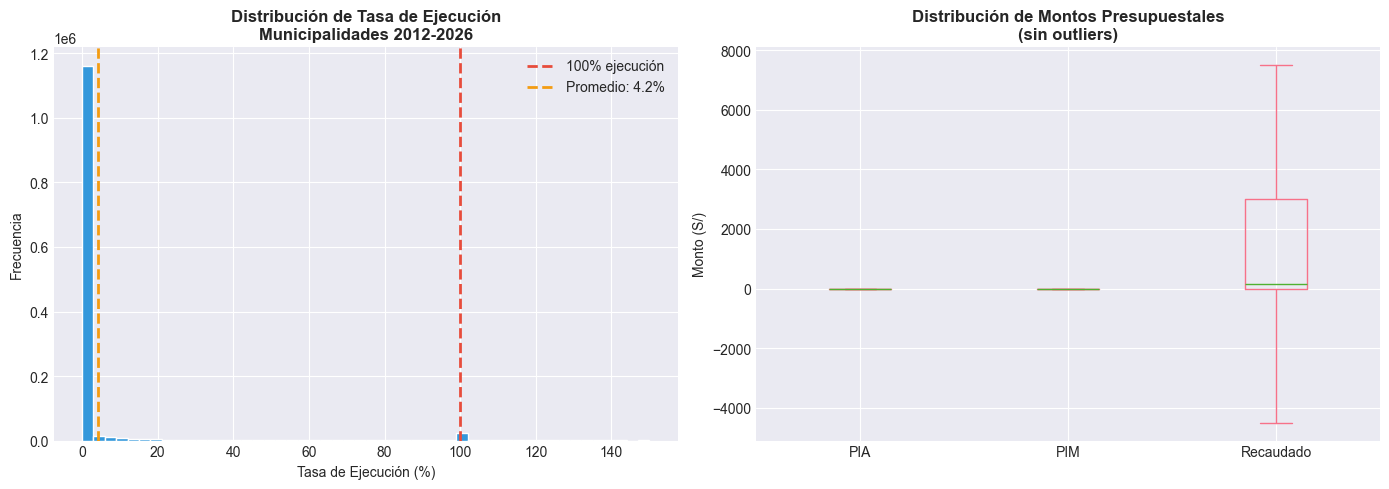

In [15]:
# Trabajamos con el filtro de municipalidades
df_munic = df[df['NIVEL_GOBIERNO'] == 'M'].copy()

# 1. Montos PIA igual a cero (municipalidad sin presupuesto inicial)
pia_cero = df_munic[df_munic['MONTO_PIA'] == 0]

# 2. Montos PIM extremadamente altos (outliers)
# Umbral: mayor a percentil 99
umbral_pim = df_munic['MONTO_PIM'].quantile(0.99)
pim_extremo = df_munic[df_munic['MONTO_PIM'] > umbral_pim]

# 3. Tasa de ejecución fuera de rango razonable
# Se espera entre 0% y 150% (algunos casos pueden superar el PIM)
df_munic['TASA_EJECUCION'] = np.where(
    df_munic['MONTO_PIM'] > 0,
    (df_munic['MONTO_RECAUDADO'] / df_munic['MONTO_PIM']) * 100,
    np.nan
)
ejecucion_invalida = df_munic[
    (df_munic['TASA_EJECUCION'] < 0) |
    (df_munic['TASA_EJECUCION'] > 150)
]

# 4. MONTO_RECAUDADO extremadamente alto
umbral_recaudado = df_munic['MONTO_RECAUDADO'].quantile(0.99)
recaudado_extremo = df_munic[df_munic['MONTO_RECAUDADO'] > umbral_recaudado]

print("=" * 60)
print("   ANÁLISIS DE RAZONABILIDAD - INGRESOS MUNICIPALIDADES")
print("=" * 60)
print(f"\nTotal registros municipalidades: {len(df_munic):,}")

print("\n📌 MONTO_PIA igual a cero:")
print("-" * 60)
print(f"⚠️  Registros con PIA = 0: {len(pia_cero):,} "
      f"({len(pia_cero)/len(df_munic)*100:.2f}%)")
print("   (puede ser normal para ingresos no planificados)")

print("\n📌 MONTO_PIM extremadamente alto (> percentil 99):")
print("-" * 60)
print(f"   Umbral percentil 99: S/ {umbral_pim:,.2f}")
print(f"⚠️  Registros con PIM extremo: {len(pim_extremo):,} "
      f"({len(pim_extremo)/len(df_munic)*100:.2f}%)")
if len(pim_extremo) > 0:
    print(pim_extremo[['ANO_DOC', 'EJECUTORA_NOMBRE',
                        'RUBRO_NOMBRE', 'MONTO_PIM']].head())

print("\n📌 Tasa de ejecución fuera de rango (0% - 150%):")
print("-" * 60)
print(f"⚠️  Registros con tasa inválida: {len(ejecucion_invalida):,} "
      f"({len(ejecucion_invalida)/len(df_munic)*100:.2f}%)")
if len(ejecucion_invalida) > 0:
    print(ejecucion_invalida[['ANO_DOC', 'EJECUTORA_NOMBRE',
                               'MONTO_PIM', 'MONTO_RECAUDADO',
                               'TASA_EJECUCION']].head())

print("\n📌 Estadísticas descriptivas de montos presupuestales:")
print("-" * 60)
resumen = df_munic[['MONTO_PIA', 'MONTO_PIM',
                    'MONTO_RECAUDADO', 'TASA_EJECUCION']].describe()

print(resumen.round(2))

# Visualización: distribución de tasa de ejecución
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma tasa de ejecución
tasa_valida = df_munic[
    (df_munic['TASA_EJECUCION'] >= 0) &
    (df_munic['TASA_EJECUCION'] <= 150)
]['TASA_EJECUCION']

axes[0].hist(tasa_valida, bins=50, color='#3498db', edgecolor='white')
axes[0].axvline(x=100, color='#e74c3c', linestyle='--',
                linewidth=2, label='100% ejecución')
axes[0].axvline(x=tasa_valida.mean(), color='#f39c12',
                linestyle='--', linewidth=2,
                label=f'Promedio: {tasa_valida.mean():.1f}%')
axes[0].set_title('Distribución de Tasa de Ejecución\nMunicipalidades 2012-2026',
                  fontweight='bold')
axes[0].set_xlabel('Tasa de Ejecución (%)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Boxplot de montos
df_munic[['MONTO_PIA', 'MONTO_PIM', 'MONTO_RECAUDADO']].plot(
    kind='box', ax=axes[1], showfliers=False
)
axes[1].set_title('Distribución de Montos Presupuestales\n(sin outliers)',
                  fontweight='bold')
axes[1].set_ylabel('Monto (S/)')
axes[1].set_xticklabels(['PIA', 'PIM', 'Recaudado'], rotation=0)

plt.tight_layout()
plt.show()

### 6. OPORTUNIDAD - Validación de Fechas

   ANÁLISIS DE OPORTUNIDAD - INGRESOS MUNICIPALIDADES

Rango esperado del proyecto: 2012 - 2026
Rango real en los datos   : 2012 - 2026
Total registros munic.    : 8,880,692

📌 Años fuera del rango esperado (2012-2026):
------------------------------------------------------------
⚠️  Registros con año fuera: 0 (0.00%)
✅ Todos los registros están dentro del rango 2012-2026

📌 Años completos faltantes en el rango:
------------------------------------------------------------
✅ Todos los años del rango están presentes: [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]

📌 Años con cantidad de registros inusualmente baja:
------------------------------------------------------------
   Promedio de registros por año: 592,046
⚠️  Años con menos del 50% del promedio:
 ANO_DOC  total_registros
    2026       

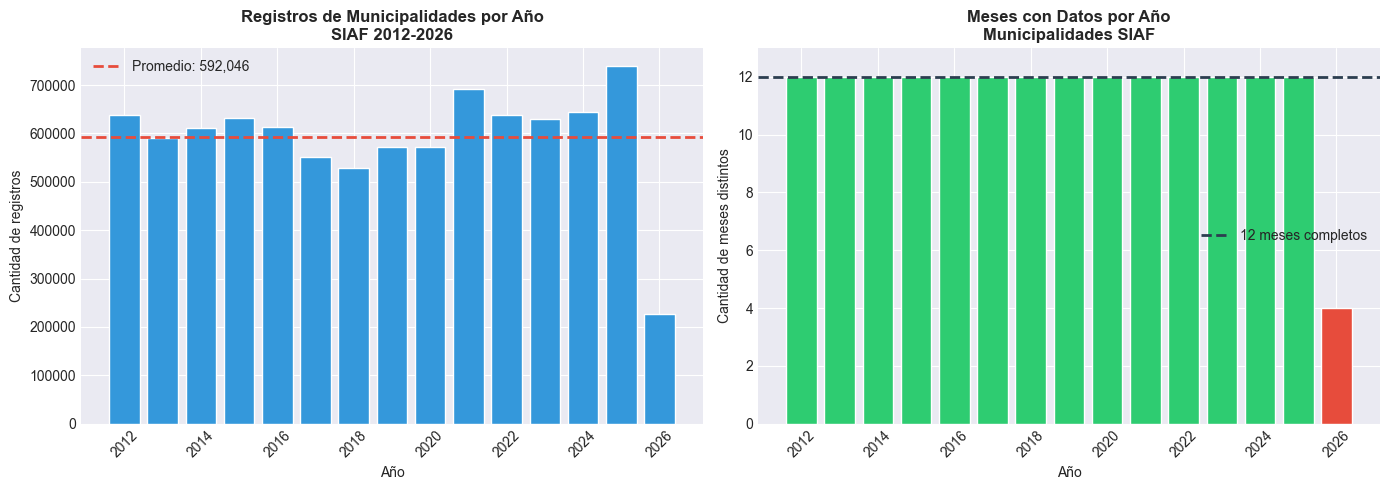

In [16]:
# OPORTUNIDAD - Validación de cobertura temporal del dataset

# Trabajamos con el filtro de municipalidades
df_munic = df[df['NIVEL_GOBIERNO'] == 'M'].copy()

# Rango esperado del proyecto
anio_inicio_esperado = 2012
anio_fin_esperado    = 2026

# 1. Verificar años fuera del rango esperado
anios_fuera = df_munic[
    (df_munic['ANO_DOC'] < anio_inicio_esperado) |
    (df_munic['ANO_DOC'] > anio_fin_esperado)
]

# 2. Verificar si hay años completos faltantes en el rango
anios_en_datos    = sorted(df_munic['ANO_DOC'].unique())
anios_esperados   = list(range(anio_inicio_esperado, anio_fin_esperado + 1))
anios_faltantes   = [a for a in anios_esperados if a not in anios_en_datos]

# 3. Contar registros por año para detectar años con poca data
registros_por_anio = df_munic.groupby('ANO_DOC').size().reset_index(
    name='total_registros'
)
promedio_registros = registros_por_anio['total_registros'].mean()
anios_bajos = registros_por_anio[
    registros_por_anio['total_registros'] < promedio_registros * 0.5
]

# 4. Verificar cobertura de meses por año
meses_por_anio = df_munic.groupby('ANO_DOC')['MES_DOC'].nunique().reset_index(
    name='meses_distintos'
)
anios_incompletos = meses_por_anio[meses_por_anio['meses_distintos'] < 12]

print("=" * 60)
print("   ANÁLISIS DE OPORTUNIDAD - INGRESOS MUNICIPALIDADES")
print("=" * 60)
print(f"\nRango esperado del proyecto: {anio_inicio_esperado} - {anio_fin_esperado}")
print(f"Rango real en los datos   : "
      f"{df_munic['ANO_DOC'].min()} - {df_munic['ANO_DOC'].max()}")
print(f"Total registros munic.    : {len(df_munic):,}")

print("\n📌 Años fuera del rango esperado (2012-2026):")
print("-" * 60)
print(f"⚠️  Registros con año fuera: {len(anios_fuera):,} "
      f"({len(anios_fuera)/len(df_munic)*100:.2f}%)")
if len(anios_fuera) > 0:
    print(anios_fuera[['ANO_DOC', 'EJECUTORA_NOMBRE',
                        'MONTO_RECAUDADO']].head())
else:
    print("✅ Todos los registros están dentro del rango 2012-2026")

print("\n📌 Años completos faltantes en el rango:")
print("-" * 60)
if anios_faltantes:
    print(f"⚠️  Años sin datos: {anios_faltantes}")
else:
    print(f"✅ Todos los años del rango están presentes: {anios_en_datos}")

print("\n📌 Años con cantidad de registros inusualmente baja:")
print("-" * 60)
print(f"   Promedio de registros por año: {promedio_registros:,.0f}")
if len(anios_bajos) > 0:
    print(f"⚠️  Años con menos del 50% del promedio:")
    print(anios_bajos.to_string(index=False))
else:
    print("✅ Todos los años tienen cobertura de registros normal")

print("\n📌 Años con meses incompletos (menos de 12 meses):")
print("-" * 60)
if len(anios_incompletos) > 0:
    print(f"⚠️  Años con meses faltantes:")
    print(anios_incompletos.to_string(index=False))
    print("   (puede ser normal para el año en curso)")
else:
    print("✅ Todos los años tienen los 12 meses representados")

# Visualización: registros por año
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras de registros por año
axes[0].bar(
    registros_por_anio['ANO_DOC'],
    registros_por_anio['total_registros'],
    color='#3498db', edgecolor='white'
)
axes[0].axhline(
    y=promedio_registros, color='#e74c3c',
    linestyle='--', linewidth=2,
    label=f'Promedio: {promedio_registros:,.0f}'
)
axes[0].set_title(
    'Registros de Municipalidades por Año\nSIAF 2012-2026',
    fontweight='bold'
)
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Cantidad de registros')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# Meses distintos por año
axes[1].bar(
    meses_por_anio['ANO_DOC'],
    meses_por_anio['meses_distintos'],
    color=['#2ecc71' if m == 12 else '#e74c3c'
           for m in meses_por_anio['meses_distintos']],
    edgecolor='white'
)
axes[1].axhline(y=12, color='#2c3e50', linestyle='--',
                linewidth=2, label='12 meses completos')
axes[1].set_title(
    'Meses con Datos por Año\nMunicipalidades SIAF',
    fontweight='bold'
)
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Cantidad de meses distintos')
axes[1].set_ylim(0, 13)
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 7. UNICIDAD - Detección de Duplicados

   ANÁLISIS DE UNICIDAD - INGRESOS MUNICIPALIDADES

Total registros municipalidades: 8,880,692

📌 Duplicados exactos (todas las columnas iguales):
------------------------------------------------------------
⚠️  Duplicados exactos: 0 (0.00%)
✅ No se encontraron duplicados exactos

📌 Duplicados parciales por clave de negocio:
   (año + mes + ejecutora + rubro + fuente + genérica + subgenérica)
------------------------------------------------------------
⚠️  Duplicados parciales: 7,693,760 (86.63%)

Ejemplos de duplicados parciales:
       ANO_DOC  MES_DOC                         EJECUTORA_NOMBRE  \
70586     2012        1  MUNICIPALIDAD PROVINCIAL DE CHACHAPOYAS   
70587     2012        1  MUNICIPALIDAD PROVINCIAL DE CHACHAPOYAS   
70588     2012        1  MUNICIPALIDAD PROVINCIAL DE CHACHAPOYAS   
70589     2012        1  MUNICIPALIDAD PROVINCIAL DE CHACHAPOYAS   
70590     2012        1  MUNICIPALIDAD PROVINCIAL DE CHACHAPOYAS   
70591     2012        1  MUNICIPALIDAD PROVINCIAL DE CH

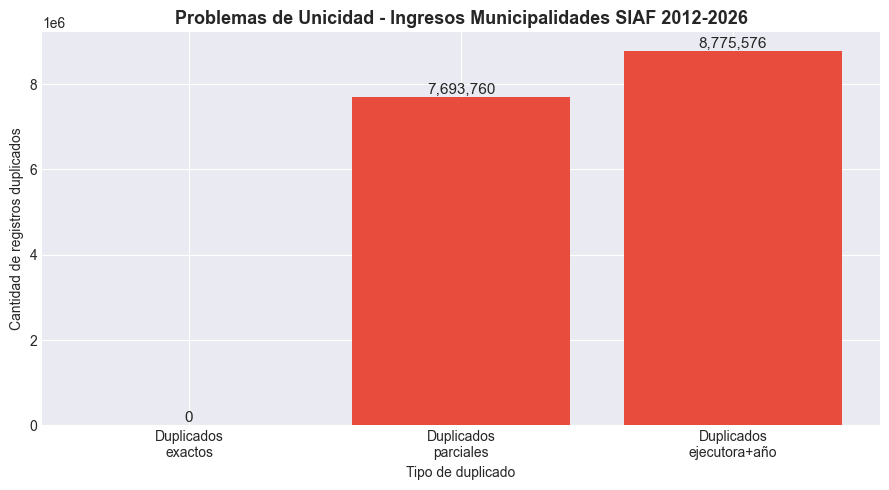

In [17]:
# UNICIDAD - Detección de registros duplicados en ingresos municipalidades

# Trabajamos con el filtro de municipalidades
df_munic = df[df['NIVEL_GOBIERNO'] == 'M'].copy()

# 1. Duplicados exactos (todas las columnas excepto ARCHIVO_ORIGEN)
columnas_comparacion = [col for col in df_munic.columns
                        if col != 'ARCHIVO_ORIGEN']
duplicados_exactos = df_munic[
    df_munic.duplicated(subset=columnas_comparacion, keep=False)
]

# 2. Duplicados parciales por clave de negocio
# Un registro de ingreso se identifica por: año, mes, ejecutora, rubro,
# fuente de financiamiento, genérica y subgenérica
clave_negocio = [
    'ANO_DOC', 'MES_DOC', 'SEC_EJEC',
    'RUBRO', 'FUENTE_FINANCIAMIENTO',
    'GENERICA', 'SUBGENERICA'
]
duplicados_parciales = df_munic[
    df_munic.duplicated(subset=clave_negocio, keep=False)
]

# 3. Duplicados por ejecutora y año (mismo municipio mismo año)
duplicados_ejec_anio = df_munic[
    df_munic.duplicated(
        subset=['ANO_DOC', 'SEC_EJEC', 'RUBRO',
                'GENERICA', 'ESPECIFICA_DET'],
        keep=False
    )
]

print("=" * 60)
print("   ANÁLISIS DE UNICIDAD - INGRESOS MUNICIPALIDADES")
print("=" * 60)
print(f"\nTotal registros municipalidades: {len(df_munic):,}")

print("\n📌 Duplicados exactos (todas las columnas iguales):")
print("-" * 60)
print(f"⚠️  Duplicados exactos: {len(duplicados_exactos):,} "
      f"({len(duplicados_exactos)/len(df_munic)*100:.2f}%)")
if len(duplicados_exactos) > 0:
    print("\nEjemplos de duplicados exactos:")
    print(duplicados_exactos[['ANO_DOC', 'MES_DOC', 'EJECUTORA_NOMBRE',
                               'RUBRO_NOMBRE', 'MONTO_PIA',
                               'MONTO_PIM', 'MONTO_RECAUDADO']].head(6))
else:
    print("✅ No se encontraron duplicados exactos")

print("\n📌 Duplicados parciales por clave de negocio:")
print("   (año + mes + ejecutora + rubro + fuente + genérica + subgenérica)")
print("-" * 60)
print(f"⚠️  Duplicados parciales: {len(duplicados_parciales):,} "
      f"({len(duplicados_parciales)/len(df_munic)*100:.2f}%)")
if len(duplicados_parciales) > 0:
    print("\nEjemplos de duplicados parciales:")
    print(duplicados_parciales[['ANO_DOC', 'MES_DOC', 'EJECUTORA_NOMBRE',
                                 'RUBRO_NOMBRE', 'MONTO_PIA',
                                 'MONTO_PIM', 'MONTO_RECAUDADO']].head(6))
else:
    print("✅ No se encontraron duplicados por clave de negocio")

print("\n📌 Duplicados por ejecutora + año + rubro + específica:")
print("-" * 60)
print(f"⚠️  Registros duplicados: {len(duplicados_ejec_anio):,} "
      f"({len(duplicados_ejec_anio)/len(df_munic)*100:.2f}%)")
if len(duplicados_ejec_anio) > 0:
    print("\nEjemplos:")
    print(duplicados_ejec_anio[['ANO_DOC', 'SEC_EJEC', 'EJECUTORA_NOMBRE',
                                 'RUBRO_NOMBRE', 'MONTO_RECAUDADO']].head(6))
else:
    print("✅ No se encontraron duplicados por ejecutora y año")

# Visualización resumen unicidad
problemas_unic = {
    'Duplicados\nexactos': len(duplicados_exactos),
    'Duplicados\nparciales': len(duplicados_parciales),
    'Duplicados\nejecutora+año': len(duplicados_ejec_anio)
}

plt.figure(figsize=(9, 5))
bars = plt.bar(
    problemas_unic.keys(),
    problemas_unic.values(),
    color=['#e74c3c' if v > 0 else '#2ecc71'
           for v in problemas_unic.values()]
)
plt.title(
    'Problemas de Unicidad - Ingresos Municipalidades SIAF 2012-2026',
    fontsize=13, fontweight='bold'
)
plt.ylabel('Cantidad de registros duplicados')
plt.xlabel('Tipo de duplicado')
for bar, val in zip(bars, problemas_unic.values()):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{val:,}',
        ha='center', va='bottom', fontsize=11
    )
plt.tight_layout()
plt.show()

### 8. VALIDEZ - Validación de Formatos

   ANÁLISIS DE VALIDEZ - INGRESOS MUNICIPALIDADES

Total registros dataset completo : 10,777,068
Total registros municipalidades  : 8,880,692

📌 Validez de NIVEL_GOBIERNO (valores válidos: E, R, M):
------------------------------------------------------------
⚠️  Niveles inválidos: 0 (0.00%)
   Valores únicos encontrados: <StringArray>
['R', 'M', 'E']
Length: 3, dtype: str
✅ Todos los valores de NIVEL_GOBIERNO son válidos

📌 Validez de RUBRO (debe ser numérico 1-2 dígitos):
------------------------------------------------------------
⚠️  Rubros con formato inválido: 0 (0.00%)
✅ Todos los códigos de RUBRO tienen formato válido
   Rubros distintos encontrados: [np.int64(7), np.int64(8), np.int64(9), np.int64(13), np.int64(18), np.int64(19)]

📌 Validez de FUENTE_FINANCIAMIENTO (valores válidos: 1-5):
------------------------------------------------------------
⚠️  Fuentes inválidas: 0 (0.00%)
✅ Todos los códigos de fuente de financiamiento son válidos
   Fuentes encontradas: [np.int64(2),

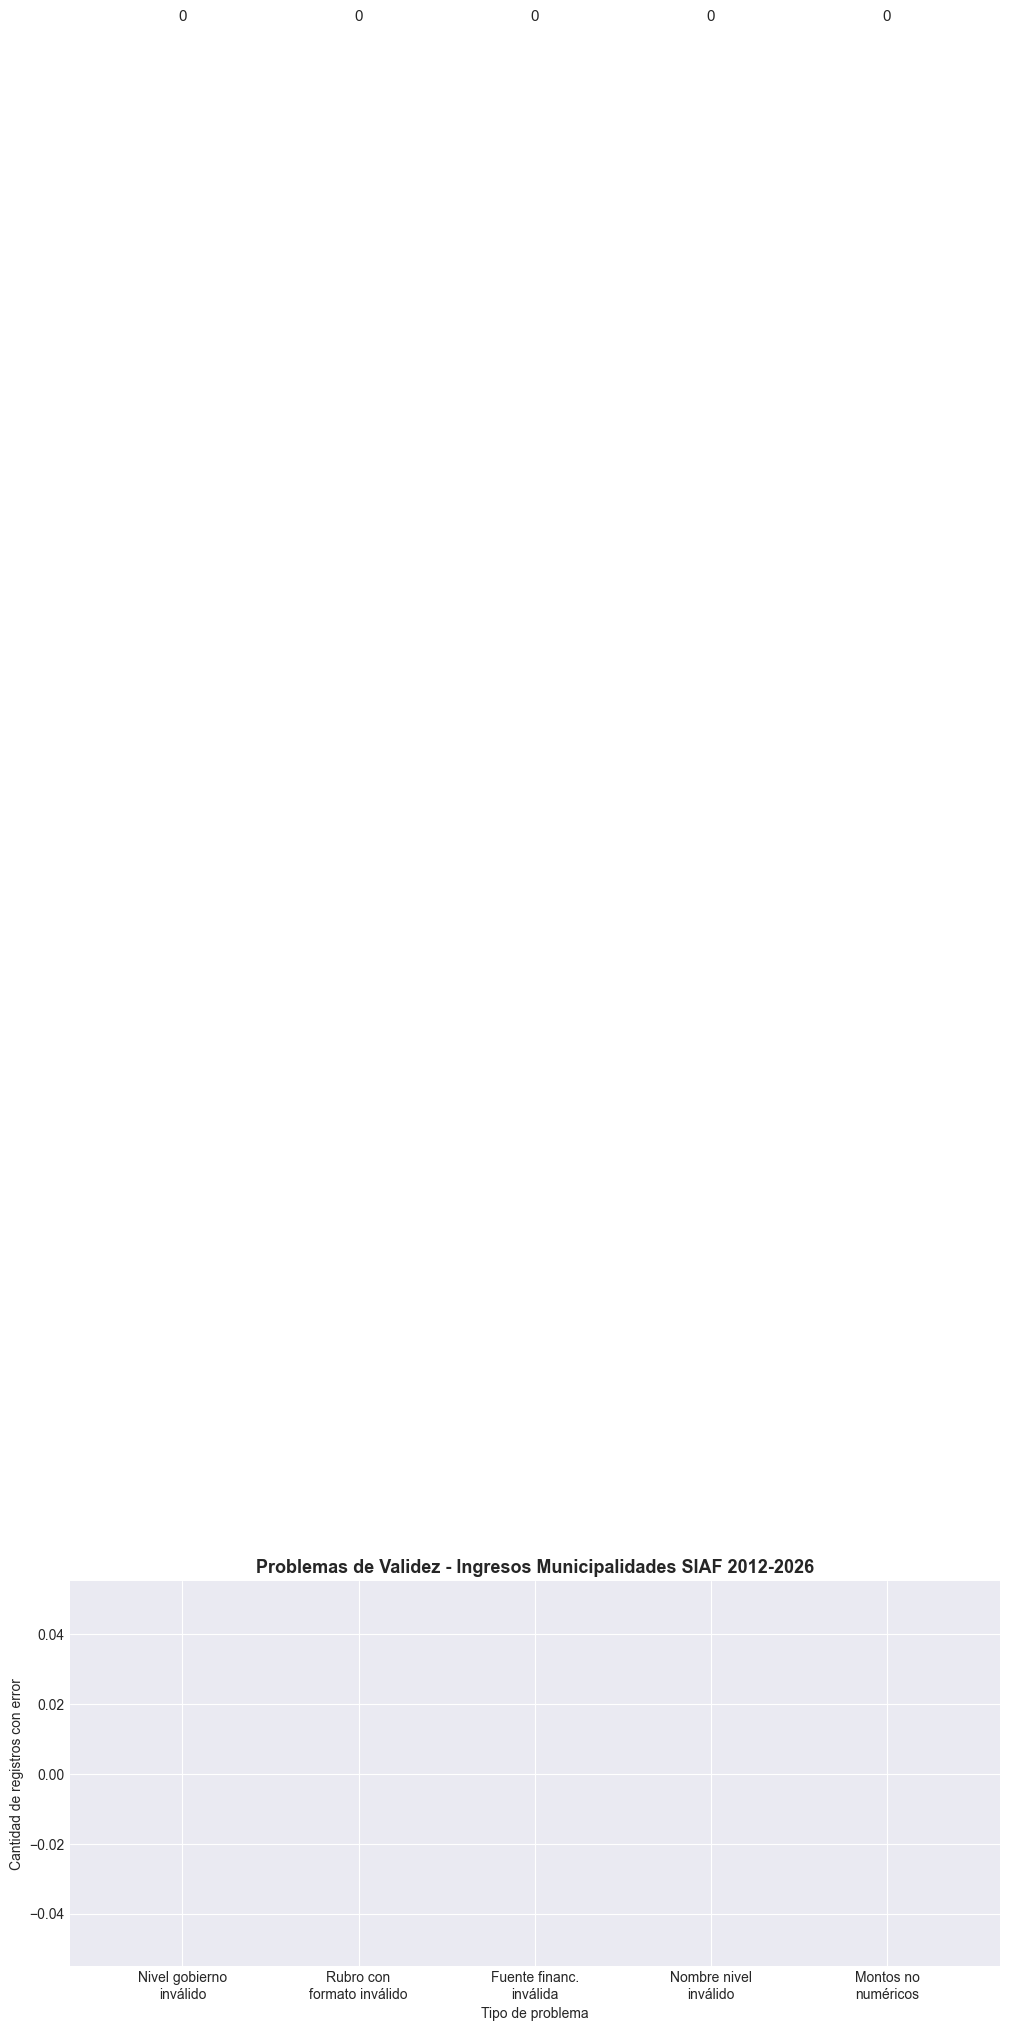

In [18]:
# Trabajamos con el filtro de municipalidades
df_munic = df[df['NIVEL_GOBIERNO'] == 'M'].copy()

# 1. Validar NIVEL_GOBIERNO (solo valores permitidos: E, R, M)
# En este dataset ya filtramos M, pero validamos que no haya otros
niveles_validos  = ['E', 'R', 'M']
nivel_invalido   = df[~df['NIVEL_GOBIERNO'].isin(niveles_validos)]

# 2. Validar RUBRO (debe ser numérico de 2 dígitos)
import re
patron_rubro = r'^\d{1,2}$'
df_munic['RUBRO_VALIDO'] = df_munic['RUBRO'].astype(str).str.match(patron_rubro)
rubro_invalido = df_munic[~df_munic['RUBRO_VALIDO']]

# 3. Validar FUENTE_FINANCIAMIENTO (valores permitidos del MEF: 1-5)
fuentes_validas      = [1, 2, 3, 4, 5]
fuente_invalida      = df_munic[
    ~df_munic['FUENTE_FINANCIAMIENTO'].isin(fuentes_validas)
]

# 4. Validar NIVEL_GOBIERNO_NOMBRE (valores permitidos)
nombres_nivel_validos = [
    'GOBIERNO NACIONAL',
    'GOBIERNOS REGIONALES',
    'GOBIERNOS LOCALES'
]
nombre_nivel_invalido = df[
    ~df['NIVEL_GOBIERNO_NOMBRE'].isin(nombres_nivel_validos)
]

# 5. Validar que MONTO_PIA, MONTO_PIM, MONTO_RECAUDADO sean numéricos
for col in ['MONTO_PIA', 'MONTO_PIM', 'MONTO_RECAUDADO']:
    df_munic[f'{col}_NUMERICO'] = pd.to_numeric(
        df_munic[col], errors='coerce'
    ).notna()

montos_no_numericos = df_munic[
    ~df_munic['MONTO_PIA_NUMERICO'] |
    ~df_munic['MONTO_PIM_NUMERICO'] |
    ~df_munic['MONTO_RECAUDADO_NUMERICO']
]

print("=" * 60)
print("   ANÁLISIS DE VALIDEZ - INGRESOS MUNICIPALIDADES")
print("=" * 60)
print(f"\nTotal registros dataset completo : {len(df):,}")
print(f"Total registros municipalidades  : {len(df_munic):,}")

print("\n📌 Validez de NIVEL_GOBIERNO (valores válidos: E, R, M):")
print("-" * 60)
print(f"⚠️  Niveles inválidos: {len(nivel_invalido):,} "
      f"({len(nivel_invalido)/len(df)*100:.2f}%)")
print(f"   Valores únicos encontrados: "
      f"{df['NIVEL_GOBIERNO'].unique()}")
if len(nivel_invalido) > 0:
    print(nivel_invalido[['ANO_DOC', 'NIVEL_GOBIERNO',
                           'NIVEL_GOBIERNO_NOMBRE',
                           'EJECUTORA_NOMBRE']].head())
else:
    print("✅ Todos los valores de NIVEL_GOBIERNO son válidos")

print("\n📌 Validez de RUBRO (debe ser numérico 1-2 dígitos):")
print("-" * 60)
print(f"⚠️  Rubros con formato inválido: {len(rubro_invalido):,} "
      f"({len(rubro_invalido)/len(df_munic)*100:.2f}%)")
if len(rubro_invalido) > 0:
    print(rubro_invalido[['ANO_DOC', 'RUBRO',
                           'RUBRO_NOMBRE',
                           'EJECUTORA_NOMBRE']].head())
else:
    print("✅ Todos los códigos de RUBRO tienen formato válido")
    print(f"   Rubros distintos encontrados: "
          f"{sorted(df_munic['RUBRO'].unique())}")

print("\n📌 Validez de FUENTE_FINANCIAMIENTO (valores válidos: 1-5):")
print("-" * 60)
print(f"⚠️  Fuentes inválidas: {len(fuente_invalida):,} "
      f"({len(fuente_invalida)/len(df_munic)*100:.2f}%)")
if len(fuente_invalida) > 0:
    print(fuente_invalida[['ANO_DOC', 'FUENTE_FINANCIAMIENTO',
                            'FUENTE_FINANCIAMIENTO_NOMBRE',
                            'EJECUTORA_NOMBRE']].head())
else:
    print("✅ Todos los códigos de fuente de financiamiento son válidos")
    print(f"   Fuentes encontradas: "
          f"{sorted(df_munic['FUENTE_FINANCIAMIENTO'].unique())}")

print("\n📌 Validez de NIVEL_GOBIERNO_NOMBRE:")
print("-" * 60)
print(f"⚠️  Nombres de nivel inválidos: {len(nombre_nivel_invalido):,} "
      f"({len(nombre_nivel_invalido)/len(df)*100:.2f}%)")
if len(nombre_nivel_invalido) > 0:
    print(nombre_nivel_invalido['NIVEL_GOBIERNO_NOMBRE'].value_counts())
else:
    print("✅ Todos los nombres de nivel de gobierno son válidos")

print("\n📌 Validez de montos (deben ser numéricos):")
print("-" * 60)
print(f"⚠️  Registros con montos no numéricos: "
      f"{len(montos_no_numericos):,} "
      f"({len(montos_no_numericos)/len(df_munic)*100:.2f}%)")
if len(montos_no_numericos) > 0:
    print(montos_no_numericos[['ANO_DOC', 'EJECUTORA_NOMBRE',
                                'MONTO_PIA', 'MONTO_PIM',
                                'MONTO_RECAUDADO']].head())
else:
    print("✅ Todos los montos tienen formato numérico válido")

# Visualización resumen validez
problemas_valid = {
    'Nivel gobierno\ninválido': len(nivel_invalido),
    'Rubro con\nformato inválido': len(rubro_invalido),
    'Fuente financ.\ninválida': len(fuente_invalida),
    'Nombre nivel\ninválido': len(nombre_nivel_invalido),
    'Montos no\nnuméricos': len(montos_no_numericos)
}

plt.figure(figsize=(12, 5))
bars = plt.bar(
    problemas_valid.keys(),
    problemas_valid.values(),
    color=['#e74c3c' if v > 0 else '#2ecc71'
           for v in problemas_valid.values()]
)
plt.title(
    'Problemas de Validez - Ingresos Municipalidades SIAF 2012-2026',
    fontsize=13, fontweight='bold'
)
plt.ylabel('Cantidad de registros con error')
plt.xlabel('Tipo de problema')
for bar, val in zip(bars, problemas_valid.values()):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{val:,}',
        ha='center', va='bottom', fontsize=11
    )
plt.tight_layout()
plt.show()

---

## Resumen Ejecutivo de Calidad de Datos

   RESUMEN EJECUTIVO - CALIDAD DE DATOS
   Ingresos Municipalidades SIAF 2012-2026

Total registros municipalidades analizados: 8,880,692

    Dimensión  Registros con Problemas  Porcentaje   Severidad
  Completitud                        0        0.00 🟢 ACEPTABLE
    Exactitud                   108001        1.22 🟢 ACEPTABLE
 Consistencia                        0        0.00 🟢 ACEPTABLE
   Integridad                       36        0.00 🟢 ACEPTABLE
Razonabilidad                   100750        1.13 🟢 ACEPTABLE
  Oportunidad                        1        0.00 🟢 ACEPTABLE
     Unicidad                  7693760       86.63   🔴 CRÍTICO
      Validez                        0        0.00 🟢 ACEPTABLE

📊 PUNTAJE GLOBAL DE CALIDAD: 88.9 / 100
   🟡 Calidad MEDIA — requiere limpieza antes de pasar a Silver


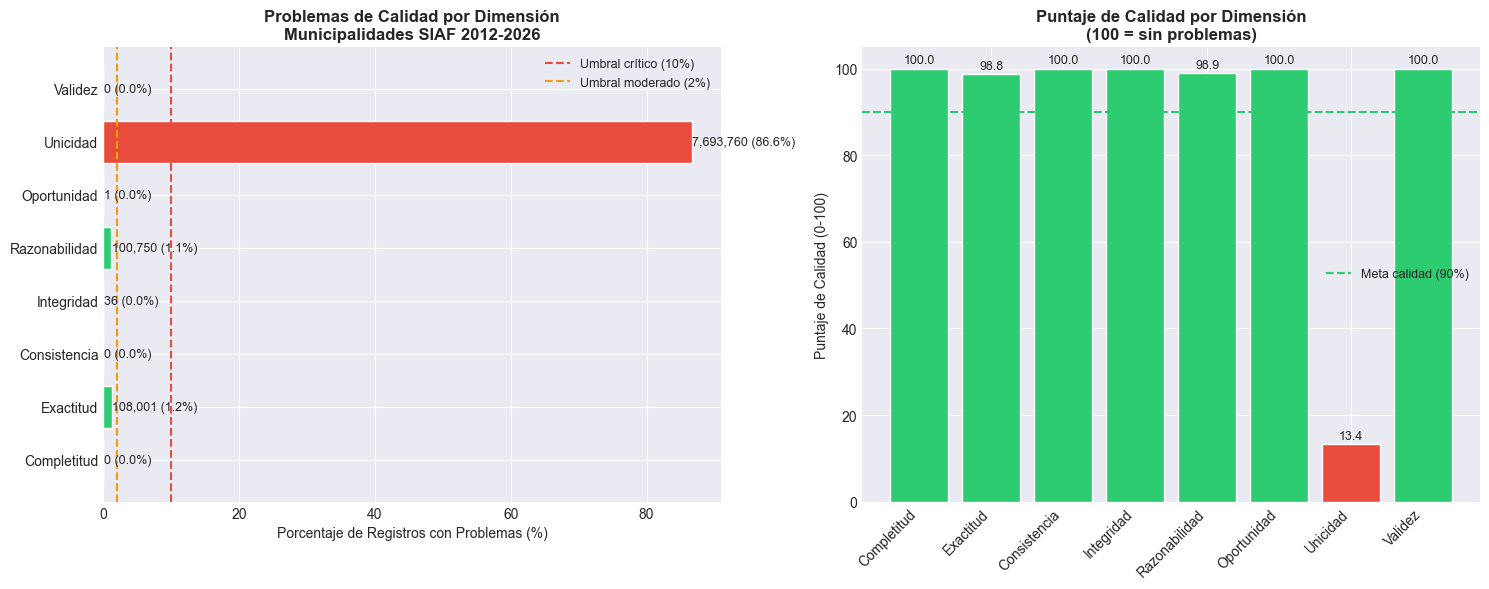

In [19]:
# RESUMEN EJECUTIVO DE CALIDAD DE DATOS - INGRESOS MUNICIPALIDADES

# Crear resumen con las variables calculadas en cada sección
resumen = {
    'Dimensión': [
        'Completitud',
        'Exactitud',
        'Consistencia',
        'Integridad',
        'Razonabilidad',
        'Oportunidad',
        'Unicidad',
        'Validez'
    ],
    'Registros con Problemas': [
        # Completitud: total de celdas nulas en columnas críticas
        df_munic[columnas_criticas].isnull().sum().sum(),
        # Exactitud: montos negativos + PIM menor que PIA
        len(pia_negativos) + len(pim_negativos) +
        len(recaudado_negativos) + len(pim_menor_pia),
        # Consistencia: nivel inconsistente + año vs archivo
        len(inconsist_nivel) + len(inconsist_anio),
        # Integridad: ubigeo inválido + dpto fuera rango +
        #             mes inválido + sec_ejec vacío
        len(ubigeo_invalido) + len(dpto_invalido) +
        len(mes_invalido) + len(sec_ejec_vacio),
        # Razonabilidad: tasa ejecución inválida + PIM extremo
        len(ejecucion_invalida) + len(pim_extremo),
        # Oportunidad: años fuera rango + años con meses incompletos
        len(anios_fuera) + len(anios_incompletos),
        # Unicidad: duplicados exactos + duplicados parciales
        len(duplicados_exactos) + len(duplicados_parciales),
        # Validez: nivel inválido + rubro inválido +
        #          fuente inválida + montos no numéricos
        len(nivel_invalido) + len(rubro_invalido) +
        len(fuente_invalida) + len(montos_no_numericos)
    ]
}

df_resumen = pd.DataFrame(resumen)
df_resumen['Porcentaje'] = (
    df_resumen['Registros con Problemas'] / len(df_munic) * 100
).round(2)
df_resumen['Severidad'] = df_resumen['Porcentaje'].apply(
    lambda x: '🔴 CRÍTICO' if x > 10
    else ('🟡 MODERADO' if x > 2
    else '🟢 ACEPTABLE')
)

print("=" * 65)
print("   RESUMEN EJECUTIVO - CALIDAD DE DATOS")
print("   Ingresos Municipalidades SIAF 2012-2026")
print("=" * 65)
print(f"\nTotal registros municipalidades analizados: {len(df_munic):,}")
print()
print(df_resumen.to_string(index=False))

# Puntaje global de calidad
puntaje = 100 - df_resumen['Porcentaje'].mean()
print(f"\n{'=' * 65}")
print(f"📊 PUNTAJE GLOBAL DE CALIDAD: {puntaje:.1f} / 100")
if puntaje >= 90:
    print("   🟢 Calidad ALTA — datos listos para Silver con ajustes menores")
elif puntaje >= 75:
    print("   🟡 Calidad MEDIA — requiere limpieza antes de pasar a Silver")
else:
    print("   🔴 Calidad BAJA — requiere limpieza exhaustiva antes de Silver")
print(f"{'=' * 65}")

# Visualización del resumen
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico horizontal de porcentaje por dimensión
colores = [
    '#e74c3c' if p > 10 else '#f39c12' if p > 2 else '#2ecc71'
    for p in df_resumen['Porcentaje']
]
axes[0].barh(
    df_resumen['Dimensión'],
    df_resumen['Porcentaje'],
    color=colores,
    edgecolor='white'
)
axes[0].axvline(x=10, color='#e74c3c', linestyle='--',
                linewidth=1.5, label='Umbral crítico (10%)')
axes[0].axvline(x=2, color='#f39c12', linestyle='--',
                linewidth=1.5, label='Umbral moderado (2%)')
axes[0].set_xlabel('Porcentaje de Registros con Problemas (%)')
axes[0].set_title(
    'Problemas de Calidad por Dimensión\nMunicipalidades SIAF 2012-2026',
    fontweight='bold'
)
for i, (val, porc) in enumerate(zip(
    df_resumen['Registros con Problemas'],
    df_resumen['Porcentaje']
)):
    axes[0].text(
        porc + 0.1, i,
        f'{val:,} ({porc:.1f}%)',
        va='center', fontsize=9
    )
axes[0].legend(fontsize=9)

# Gráfico de radar / puntaje por dimensión
puntajes_dim = (100 - df_resumen['Porcentaje']).clip(0, 100)
axes[1].bar(
    range(len(df_resumen)),
    puntajes_dim,
    color=colores,
    edgecolor='white'
)
axes[1].axhline(y=90, color='#2ecc71', linestyle='--',
                linewidth=1.5, label='Meta calidad (90%)')
axes[1].set_xticks(range(len(df_resumen)))
axes[1].set_xticklabels(
    df_resumen['Dimensión'], rotation=45, ha='right'
)
axes[1].set_ylabel('Puntaje de Calidad (0-100)')
axes[1].set_ylim(0, 105)
axes[1].set_title(
    'Puntaje de Calidad por Dimensión\n(100 = sin problemas)',
    fontweight='bold'
)
for i, val in enumerate(puntajes_dim):
    axes[1].text(
        i, val + 0.5,
        f'{val:.1f}',
        ha='center', va='bottom', fontsize=9
    )
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()